# Baseline Sentiment Classification (TF-IDF)

This notebook builds classical machine-learning baselines
for Arabic sentiment analysis using TF-IDF features.


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
import pandas as pd

In [11]:
train_data = pd.read_csv('../data/processed/train.csv')
val_data = pd.read_csv('../data/processed/val.csv')

In [5]:
train_data.head()

,label,text
0,Positive,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...
1,Positive,احد اسباب نجاح الامارات ان كل شخص في هذه الدول...
2,Positive,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الي...
3,Positive,خلصنا .. مبدءيا اللي مستني ابهار زي الفيل الاز...
4,Positive,ياسات جلوريا جزء لا يتجزا من دبي . فندق متكامل...


In [9]:
train_data['text'][0]

'ممتاز نوعا ما . النظافة والموقع والتجهيز والشاطيء. المطعم'

In [10]:
x_train = train_data['text'].values
y_train = train_data['label'].values
x_val = val_data['text'].values
y_val = val_data['label'].values

In [13]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000,
    min_df=5
)

x_train_tfidf = tfidf.fit_transform(x_train)
x_val_tfidf   = tfidf.transform(x_val)


In [23]:
model = LogisticRegression(max_iter=1000, n_jobs=-1, class_weight='balanced')


model.fit(x_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [24]:
y_pred = model.predict(x_val_tfidf)

In [25]:
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

       Mixed       0.00      0.00      0.00         0
    Negative       1.00      0.69      0.81     10000
    Positive       0.00      0.00      0.00         0

    accuracy                           0.69     10000
   macro avg       0.33      0.23      0.27     10000
weighted avg       1.00      0.69      0.81     10000



c:\Users\pc\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pc\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pc\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

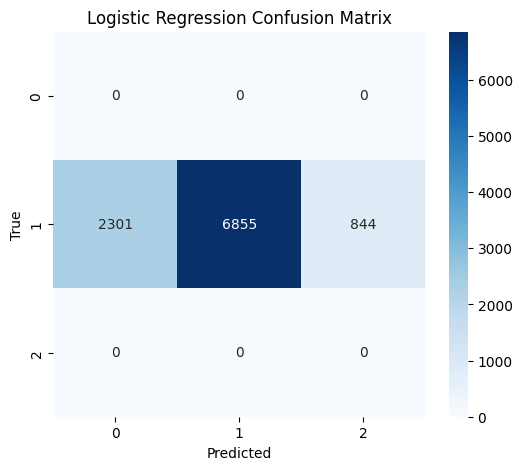

In [26]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Logistic Regression Confusion Matrix")
plt.show()
